In [17]:
import yfinance as yf
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

In [37]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN"]
data = yf.download(tickers, start="2026-01-01", end="2026-09-23", group_by='ticker')

[*********************100%***********************]  4 of 4 completed


In [38]:
frames = []
for ticker in tickers:
    df = data[ticker].copy()
    df['ticker'] = ticker
    df.reset_index(inplace=True)
    frames.append(df)

long_data = pd.concat(frames, ignore_index=True)
long_data.columns.name = None
long_data.head()

,Date,Open,High,Low,Close,Volume,ticker
0,2026-01-02,271.520960,277.085800,268.269799,270.274353,37838100,AAPL
1,2026-01-05,269.905376,270.773009,265.417591,266.534546,45647200,AAPL
2,2026-01-06,266.275247,266.823742,261.408488,261.647827,52352100,AAPL
3,2026-01-07,262.485556,262.964234,259.104744,259.623322,48309800,AAPL
4,2026-01-08,256.322286,258.586144,255.005878,258.336823,50419300,AAPL


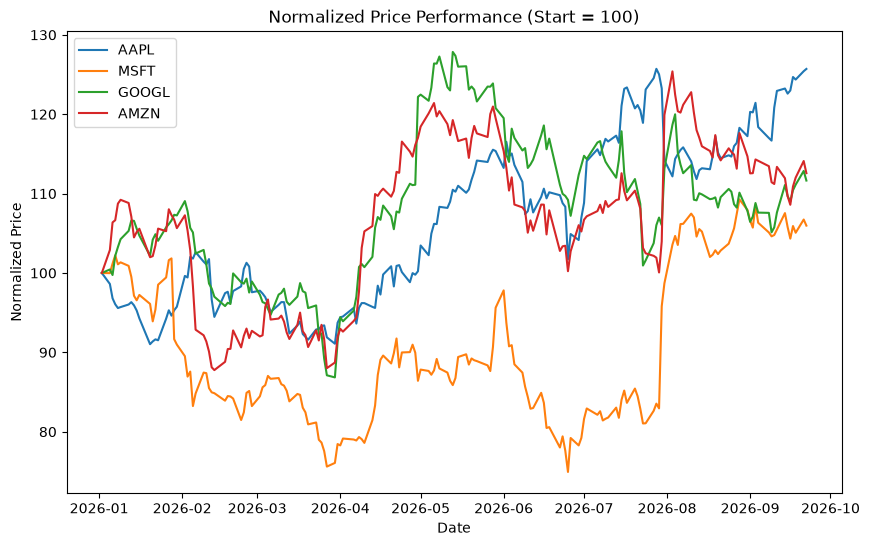

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

for ticker in tickers:
    ticker_data = long_data[long_data['ticker'] == ticker].copy()
    ticker_data['normalized'] = ticker_data['Close'] / ticker_data['Close'].iloc[0] * 100
    ax.plot(ticker_data['Date'], ticker_data['normalized'], label=ticker)

ax.set_title('Normalized Price Performance (Start = 100)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price')
ax.legend()
plt.show()

In [14]:
data.to_csv('../data/aapl_2026.csv', index=False)

In [42]:
conn = sqlite3.connect('../data/finance.db')
long_data.to_sql('prices', conn, if_exists='replace', index=False)

724

In [43]:
# Average daily return per ticker (need returns first)
query1 = """
SELECT ticker, AVG(daily_return) as avg_return
FROM (
    SELECT ticker, Date, Close,
           Close - LAG(Close) OVER (PARTITION BY ticker ORDER BY Date) as daily_return
    FROM prices
)
GROUP BY ticker
"""
pd.read_sql(query1, conn)

,ticker,avg_return
0,AAPL,0.385976
1,AMZN,0.158222
2,GOOGL,0.203455
3,MSFT,0.155786


In [44]:
# Highest single-day volume per ticker
query2 = """
SELECT ticker, MAX(Volume) as max_volume
FROM prices
GROUP BY ticker
"""
pd.read_sql(query2, conn)

,ticker,max_volume
0,AAPL,261775500
1,AMZN,248372100
2,GOOGL,114706300
3,MSFT,186201600


In [45]:
# Get all rows for just AAPL
q1 = """
SELECT *
FROM prices
WHERE ticker = 'AAPL'
"""
pd.read_sql(q1, conn)

,Date,Open,High,Low,Close,Volume,ticker
0,2026-01-02 00:00:00,271.520960,277.085800,268.269799,270.274353,37838100,AAPL
1,2026-01-05 00:00:00,269.905376,270.773009,265.417591,266.534546,45647200,AAPL
2,2026-01-06 00:00:00,266.275247,266.823742,261.408488,261.647827,52352100,AAPL
3,2026-01-07 00:00:00,262.485556,262.964234,259.104744,259.623322,48309800,AAPL
4,2026-01-08 00:00:00,256.322286,258.586144,255.005878,258.336823,50419300,AAPL
...,...,...,...,...,...,...,...
176,2026-09-16 00:00:00,332.529999,335.480011,330.700012,332.410004,35981000,AAPL
177,2026-09-17 00:00:00,334.769989,338.339996,330.179993,337.000000,36700200,AAPL
178,2026-09-18 00:00:00,337.910004,338.489990,332.529999,336.130005,86588200,AAPL
179,2026-09-21 00:00:00,335.279999,339.640015,333.049988,338.980011,34999200,AAPL


In [46]:
# Get all rows where the closing price was above $200, for any ticker
q2 = """
SELECT *
FROM prices
WHERE CLOSE > 200
"""
pd.read_sql(q2, conn)

,Date,Open,High,Low,Close,Volume,ticker
0,2026-01-02 00:00:00,271.520960,277.085800,268.269799,270.274353,37838100,AAPL
1,2026-01-05 00:00:00,269.905376,270.773009,265.417591,266.534546,45647200,AAPL
2,2026-01-06 00:00:00,266.275247,266.823742,261.408488,261.647827,52352100,AAPL
3,2026-01-07 00:00:00,262.485556,262.964234,259.104744,259.623322,48309800,AAPL
4,2026-01-08 00:00:00,256.322286,258.586144,255.005878,258.336823,50419300,AAPL
...,...,...,...,...,...,...,...
716,2026-09-16 00:00:00,248.100006,249.259995,244.300003,245.960007,33488500,AMZN
717,2026-09-17 00:00:00,251.070007,252.729996,249.240005,251.190002,30438800,AMZN
718,2026-09-18 00:00:00,252.919998,255.429993,251.880005,253.710007,52274700,AMZN
719,2026-09-21 00:00:00,256.399994,259.489990,253.600006,258.450012,42979400,AMZN


In [50]:
#Get the 5 most recent rows for MSFT, ordered by date descending.
q3 = """
SELECT *
FROM prices
WHERE ticker = 'MSFT'
ORDER BY Date DESC
LIMIT 5
"""
pd.read_sql(q3, conn)

,Date,Open,High,Low,Close,Volume,ticker
0,2026-09-22 00:00:00,507.320007,508.500000,493.649994,498.000000,21652800,MSFT
1,2026-09-21 00:00:00,494.950012,501.869995,491.329987,501.609985,27959900,MSFT
2,2026-09-18 00:00:00,497.970001,498.649994,491.100006,493.779999,39622300,MSFT
3,2026-09-17 00:00:00,497.799988,501.470001,493.170013,497.750000,17841600,MSFT
4,2026-09-16 00:00:00,493.029999,495.970001,487.230011,490.299988,16670300,MSFT


In [54]:
#Find the average closing price per ticker
q4 = """
SELECT ticker, AVG(Close) as avg_close
FROM prices
GROUP BY ticker
"""
pd.read_sql(q4, conn)

,ticker,avg_close
0,AAPL,287.776530
1,AMZN,241.788453
2,GOOGL,340.203172
3,MSFT,424.975279


In [55]:
#Find the minimum and maximum closing price per ticker.
q5 = """
SELECT ticker, MIN(Close) as min_close, MAX(Close) as max_close
FROM prices
GROUP BY ticker
"""
pd.read_sql(q5, conn)

,ticker,min_close,max_close
0,AAPL,246.030319,339.786926
1,AMZN,198.789993,284.019989
2,GOOGL,273.161163,402.121185
3,MSFT,352.167023,513.530029


In [57]:
#Count how many rows exist per ticker (sanity check that all 4 have the same number of trading days).
q6 = """
SELECT ticker, COUNT(*) as counts
FROM prices
GROUP BY ticker
"""
pd.read_sql(q6, conn)

,ticker,counts
0,AAPL,181
1,AMZN,181
2,GOOGL,181
3,MSFT,181


In [63]:
#Find tickers whose average volume is above 50 million.
q7 = """
SELECT ticker, AVG(Volume) as avg_vol
FROM prices
GROUP BY ticker
HAVING AVG(Volume) > 5e6
"""
pd.read_sql(q7, conn)

,ticker,avg_vol
0,AAPL,4.978928e+07
1,AMZN,4.735395e+07
2,GOOGL,3.112693e+07
3,MSFT,3.525314e+07


In [69]:
#For each ticker, calculate the day-over-day change in closing price (hint: LAG() like in the earlier example).
q8 = """
SELECT ticker, Date, Close, 100 - 100*LAG(Close)OVER (PARTITION BY ticker ORDER BY Date)/Close as percent_change
FROM prices
"""
pd.read_sql(q8, conn)

,ticker,Date,Close,percent_change
0,AAPL,2026-01-02 00:00:00,270.274353,NaN
1,AAPL,2026-01-05 00:00:00,266.534546,-1.403123
2,AAPL,2026-01-06 00:00:00,261.647827,-1.867670
3,AAPL,2026-01-07 00:00:00,259.623322,-0.779786
4,AAPL,2026-01-08 00:00:00,258.336823,-0.497993
...,...,...,...,...
719,MSFT,2026-09-16 00:00:00,490.299988,-1.390987
720,MSFT,2026-09-17 00:00:00,497.750000,1.496738
721,MSFT,2026-09-18 00:00:00,493.779999,-0.804002
722,MSFT,2026-09-21 00:00:00,501.609985,1.560971


In [87]:
#For each ticker, find the single day with the highest daily volume, using RANK() or ROW_NUMBER() partitioned by ticker.
q9 = """
WITH RankedData AS (
    SELECT 
        ticker,
        Date,
        Volume,
        RANK() OVER (PARTITION BY ticker ORDER BY Volume DESC) AS volume_rank
    FROM prices
)
SELECT ticker, Date, Volume, volume_rank
FROM RankedData
WHERE volume_rank = 1;
"""
pd.read_sql(q9, conn)

,ticker,Date,Volume,volume_rank
0,AAPL,2026-06-26 00:00:00,261775500,1
1,AMZN,2026-06-26 00:00:00,248372100,1
2,GOOGL,2026-06-26 00:00:00,114706300,1
3,MSFT,2026-06-26 00:00:00,186201600,1
